In [1]:
import pickle
import torch
import numpy as np

with open('./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/sample1/args.pickle', 'rb') as f:
    args = pickle.load(f)

In [5]:
print(args)

Namespace(debug=0, epochs=1000, seed=2, device='cuda', parallel=None, resume=None, need_regularization=False, name='2025-06-09_16-04-51', project='amazon_cross_diffusion_discrete_boxcox_200_tgt_len_20', eval_every=50, check_every=2, log_tb=True, log_home='.', eval_num_samples=5, distance_del_cost=[0.05, 0.5, 1, 1.5, 2, 3, 4], trans_cost=1.0, dataset='amazon', dataset_dir='./data/amazon', validation=True, tgt_len=20, boxcox=True, feature=True, batch_size=1024, num_workers=1, pin_memory=False, diffusion_steps=200, transformer_dim=32, transformer_heads=2, num_encoder_layers=1, dim_feedforward=64, num_decoder_layers=1, optimizer='adam', lr=0.0005, warmup=None, update_freq=1, momentum=0.9, momentum_sqr=0.999, gamma=0.99, scheduler='cosanneal', grad_norm=False, no_grad_norm=True, model=None, num_samples=1, filter=False, num_seqs_analysis=40, train_lambda_boxcox=np.float64(0.7389405452942325), scale=tensor(22.9253), train_mean=tensor(0.5345), train_std=tensor(0.3363), train_min=tensor(0.0100)

In [6]:
args.seed = 1

In [ ]:
args.log_path = './log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51'

In [ ]:
path_samples='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200', 
path_samples_result='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200/result.txt', 
path_samples_dt='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200/samples_dt.pt', 
path_samples_chain_dt='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200/samples_chain_dt.pt', 
path_samples_type='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200/samples_type.pt', 
path_samples_chain_type='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200/samples_type.pt', 
path_gt_dt='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200/gt_dt.pt', 
path_gt_type='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200/gt_type.pt'

In [63]:
import torch



samples_dt_20 = torch.load('./nullsamples/amazon20/1_20/samples_dt.pt')
samples_type_20 = torch.load('./nullsamples/amazon20/1_20/samples_type.pt')
samples_dt_40 = torch.load('./nullsamples/amazon20/21_40/samples_dt.pt')
samples_type_40 = torch.load('./nullsamples/amazon20/21_40/samples_type.pt')
samples_dt_60 = torch.load('./nullsamples/amazon20/41_60/samples_dt.pt')
samples_type_60 = torch.load('./nullsamples/amazon20/41_60/samples_type.pt')
samples_dt_80 = torch.load('./nullsamples/amazon20/61_80/samples_dt.pt')
samples_type_80 = torch.load('./nullsamples/amazon20/61_80/samples_type.pt')
samples_dt_100 = torch.load('./nullsamples/amazon20/81_100/samples_dt.pt')
samples_type_100 = torch.load('./nullsamples/amazon20/81_100/samples_type.pt')

In [54]:
samples_dt_20[0]

tensor([[0.7673],
        [0.0129],
        [0.0136],
        [0.0112],
        [0.7982],
        [0.0123],
        [0.0123],
        [0.7766],
        [0.7781],
        [0.7019],
        [0.7114],
        [0.7588],
        [0.0135],
        [0.0127],
        [0.7677],
        [0.7467],
        [0.7592],
        [0.7581],
        [0.7356],
        [0.0138]], dtype=torch.float64)

In [15]:
with open('./data/amazon/test.pkl', 'rb') as f:
    test = pickle.load(f)

In [23]:
test['dim_process']

16

In [ ]:
test['test'][:30]

In [48]:

# tensors already loaded: samples_dt (500, 20, 1), samples_type (500, 20, 1)

sequences = []
for i in range(samples_dt.size(0)):
    dt  = samples_dt[i, :, 0].tolist()      # 20 floats
    typ = samples_type[i, :, 0].tolist()    # 20 ints

    seq, t_cum = [], 0.0
    for d, k in zip(dt, typ):
        t_cum += d
        seq.append({
            'type_event': int(k),
            'time_since_last_event': float(d),
            'time_since_start': t_cum
        })

    # pad = 40 - len(seq)                     # 20 zeros
    pad = 20
    seq.extend([{
        'type_event': 0,
        'time_since_last_event': 0,
        'time_since_start': 0
    }] * pad)

    sequences.append(seq)                   # length 40

out = {
    'dim_process': 16,
    'test': sequences                      # length 500
}

with open('test.pkl', 'wb') as f:
    pickle.dump(out, f)

In [52]:
len(out['test'][0])

40

In [ ]:

# tensors already loaded: samples_dt (500, 20, 1), samples_type (500, 20, 1)

sequences = []
for i in range(samples_dt_20.size(0)):
    dt  = samples_dt_20[i, :, 0].tolist()      # 20 floats
    typ = samples_type_20[i, :, 0].tolist()    # 20 ints

    seq, t_cum = [], 0.0
    for d, k in zip(dt, typ):
        t_cum += d
        seq.append({
            'type_event': int(k),
            'time_since_last_event': float(d),
            'time_since_start': t_cum
        })

    # pad = 40 - len(seq)                     # 20 zeros
    pad = 20
    seq.extend([{
        'type_event': 0,
        'time_since_last_event': 0,
        'time_since_start': 0
    }] * pad)

    sequences.append(seq)                   # length 40

out = {
    'dim_process': 16,
    'test': sequences                      # length 500
}

with open('test.pkl', 'wb') as f:
    pickle.dump(out, f)

In [72]:
N = samples_dt_20.size(0)          # 500
sequences = []

for i in range(N):
    dt_part1  = samples_dt_20[i, :, 0].tolist()   # 20
    typ_part1 = samples_type_20[i, :, 0].tolist()

    dt_part2  = samples_dt_40[i, :, 0].tolist()   # 20
    typ_part2 = samples_type_40[i, :, 0].tolist()

    dt_part3  = samples_dt_60[i, :, 0].tolist()   # 20
    typ_part3 = samples_type_60[i, :, 0].tolist()

    dt_part4  = samples_dt_80[i, :, 0].tolist()   # 20
    typ_part4 = samples_type_80[i, :, 0].tolist()

    dt_part5  = samples_dt_80[i, :, 0].tolist()   # 20
    typ_part5 = samples_type_80[i, :, 0].tolist()

    dt_all  = dt_part1  + dt_part2  + dt_part3  + dt_part4  +  dt_part5             # 40
    typ_all = typ_part1 + typ_part2 + typ_part3 +  typ_part4  +   typ_part5

    seq, t_cum = [], 0.0
    for d, k in zip(dt_all, typ_all):
        t_cum += d
        seq.append({
            'type_event': int(k),
            'time_since_last_event': float(d),
            'time_since_start': t_cum
        })

    # pad = 20                                      
    # seq.extend([{
    #     'type_event': 0,
    #     'time_since_last_event': 0,
    #     'time_since_start': 0
    # } for _ in range(pad)])

    sequences.append(seq)                    

dataset = {
    'dim_process': 16,
    'generated': sequences
}

with open('generated.pkl', 'wb') as f:
    pickle.dump(dataset, f)


In [74]:
len(dataset['generated'])

500

In [92]:
m = 0
seq_last_time = []
for i in range(500):
    print("For sequence:",i,"",dataset['generated'][i][-1]['time_since_start'])
    seq_last_time.append(dataset['generated'][i][-1]['time_since_start'])
    m = max(dataset['generated'][i][-1]['time_since_start'], m)

For sequence: 0  56.75131034251484
For sequence: 1  51.848460908175525
For sequence: 2  63.19739016085625
For sequence: 3  42.002566535070514
For sequence: 4  52.07884513579949
For sequence: 5  59.459201893736015
For sequence: 6  53.9197277442817
For sequence: 7  62.8890474739275
For sequence: 8  51.70392752730847
For sequence: 9  51.50318454520166
For sequence: 10  55.60664886776008
For sequence: 11  42.459643895462186
For sequence: 12  47.33644309651223
For sequence: 13  50.99265682565187
For sequence: 14  43.84871266428481
For sequence: 15  53.57236501528061
For sequence: 16  48.2670576276731
For sequence: 17  51.78095228838084
For sequence: 18  51.813539962515165
For sequence: 19  48.128400756559444
For sequence: 20  57.48216542833722
For sequence: 21  62.38324700907769
For sequence: 22  55.969662967558854
For sequence: 23  54.25825930617334
For sequence: 24  42.98100643174847
For sequence: 25  43.60560055357015
For sequence: 26  59.497831511006126
For sequence: 27  43.947389334648

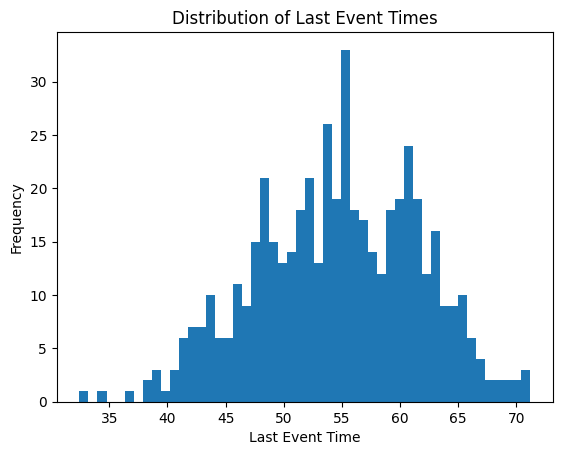

In [93]:
import matplotlib.pyplot as plt
plt.hist(seq_last_time, bins=50)
plt.xlabel("Last Event Time")
plt.ylabel("Frequency")
plt.title("Distribution of Last Event Times")
plt.show()